In [1]:
# ======================
# IMPORTS & CONFIGURATION
# ======================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd
import re
import math
from collections import Counter, defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

# Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# HYPERPARAMETERS
MAX_SEQ_LEN = 50
BATCH_SIZE = 32      # Increased for faster training
EMBED_DIM = 64      # REDUCED from 512 (4x smaller!)
NUM_HEADS = 2        # Reduced from 8
NUM_ENCODER_LAYERS = 1  # Keep or reduce to 2
NUM_DECODER_LAYERS = 1  # Keep or reduce to 2
DROPOUT = 0.4        # Increased for regularization
LEARNING_RATE = 3e-4 # Slightly higher for faster convergence
NUM_EPOCHS = 30      # More epochs since smaller model
BEAM_SIZE = 3        # Smaller for faster inference

# Curriculum Learning
CURRICULUM_STAGES = [0.3, 0.6, 1.0]  # Progressive training
REVERSE_SOURCE = True  # Reverse input technique

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>" 
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


📥 Loading data...
✅ Loaded 68849 training pairs
✅ Loaded 9836 validation sources
Loaded 68849 English–Bengali sentence pairs
📊 English - Mean: 16.8, Max: 100, 95th %ile: 32.0
📊 Bengali - Mean: 14.3, Max: 84, 95th %ile: 27.0


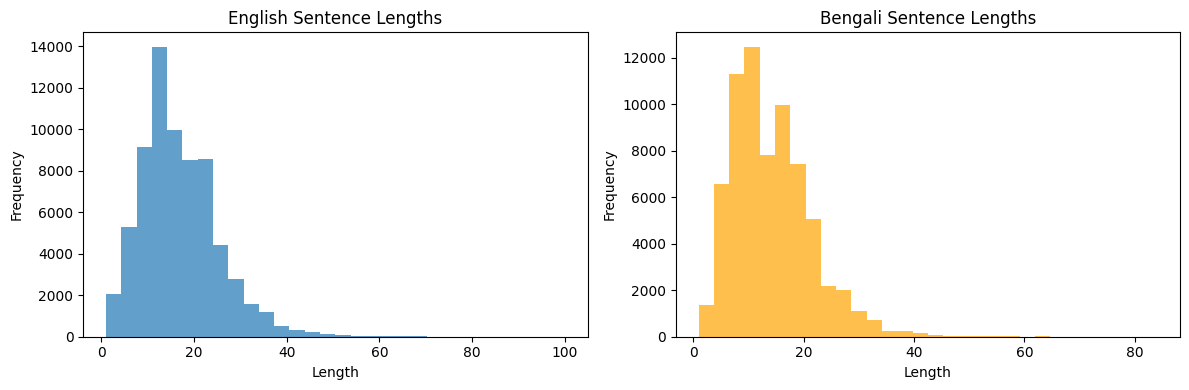

🎯 Recommended MAX_SEQ_LEN: 37


In [2]:
# ======================
# 📦 DATA LOADING & ANALYSIS
# ======================
import json
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# DATA LOADING
# -----------------------
TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH   = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

print("📥 Loading data...")


"""Load English-Bengali sentence pairs from train and validation JSONs."""
# --- Load train data ---
with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    data_train = json.load(f)

source_sentences_train, target_sentences_train, id_train = [], [], []
for language_pair, language_data in data_train.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                source = entry_data["source"]
                target = entry_data.get("target", "")
                if data_type == "Validation":
                    # skip, we’ll use the official val file
                    continue
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

# --- Load validation data ---
with open(VAL_PATH, 'r', encoding='utf-8') as f:
    data_val = json.load(f)

source_sentences_val, target_sentences_val, id_val = [], [], []
for language_pair, language_data in data_val.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                if data_type == "Test":
                    source_sentences_val.append(entry_data["source"])
                    id_val.append(entry_id)
                elif data_type == "Validation":
                    source_sentences_val.append(entry_data["source"])
                    target_sentences_val.append(entry_data.get("target", ""))
                    id_val.append(entry_id)

print(f"✅ Loaded {len(source_sentences_train)} training pairs")
print(f"✅ Loaded {len(source_sentences_val)} validation sources")

# Combine for analysis (you can later split again)
en_sentences = source_sentences_train
bn_sentences = target_sentences_train

print(f"Loaded {len(en_sentences)} English–Bengali sentence pairs")

# -----------------------
# LENGTH ANALYSIS
# -----------------------
def analyze_sequence_lengths(en_sentences, bn_sentences):
    """Analyze sequence lengths to set optimal MAX_SEQ_LEN."""
    en_lengths = [len(sent.split()) for sent in en_sentences]
    bn_lengths = [len(sent.split()) for sent in bn_sentences]

    print(f"📊 English - Mean: {np.mean(en_lengths):.1f}, Max: {max(en_lengths)}, 95th %ile: {np.percentile(en_lengths, 95):.1f}")
    print(f"📊 Bengali - Mean: {np.mean(bn_lengths):.1f}, Max: {max(bn_lengths)}, 95th %ile: {np.percentile(bn_lengths, 95):.1f}")

    # Plot histograms
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(en_lengths, bins=30, alpha=0.7)
    plt.title('English Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(bn_lengths, bins=30, alpha=0.7, color='orange')
    plt.title('Bengali Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Recommend optimal MAX_SEQ_LEN
    recommended_len = max(np.percentile(en_lengths, 95), np.percentile(bn_lengths, 95))
    print(f"🎯 Recommended MAX_SEQ_LEN: {int(recommended_len + 5)}")


# -----------------------
# RUN
# -----------------------

analyze_sequence_lengths(en_sentences, bn_sentences)

In [3]:
# ======================
# PREPROCESSING & TOKENIZATION
# ======================
def preprocess_english(text):
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def preprocess_bengali(text):
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[৷]', '।', text)
    return text

def reverse_sentences(sentences):
    return [" ".join(reversed(sent.split())) for sent in sentences]

class Vocabulary:
    def __init__(self, sentences, min_freq=2):
        self.min_freq = min_freq
        self.build_vocab(sentences)
    
    def build_vocab(self, sentences):
        word_freq = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_freq.update(words)
        
        self.itos = SPECIAL_TOKENS.copy()
        self.stoi = {token: i for i, token in enumerate(SPECIAL_TOKENS)}
        
        for word, freq in word_freq.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.itos.append(word)
                self.stoi[word] = len(self.itos) - 1
    
    def encode(self, text):
        tokens = text.split()
        return [self.stoi.get(token, self.stoi[UNK_TOKEN]) for token in tokens]
    
    def decode(self, indices):
        return [self.itos[idx] for idx in indices if self.itos[idx] not in SPECIAL_TOKENS[1:]]
    
    def __len__(self):
        return len(self.itos)

# Preprocess data
print("🔧 Preprocessing data...")
en_processed = [preprocess_english(sent) for sent in en_sentences]
bn_processed = [preprocess_bengali(sent) for sent in bn_sentences]

if REVERSE_SOURCE:
    print("🔄 Applying reverse input technique...")
    en_processed = reverse_sentences(en_processed)

# Split data
en_train, en_val, bn_train, bn_val = train_test_split(
    en_processed, bn_processed, test_size=0.1, random_state=SEED
)

print(f"Training: {len(en_train)} pairs, Validation: {len(en_val)} pairs")

🔧 Preprocessing data...
🔄 Applying reverse input technique...
Training: 61964 pairs, Validation: 6885 pairs


In [4]:
# ======================
# VOCABULARY BUILDING - FIXED
# ======================
# ======================
# VOCABULARY BUILDING
# ======================
print("📚 Building vocabularies...")
src_vocab = Vocabulary(en_train + en_val, min_freq=1)
tgt_vocab = Vocabulary(bn_train + bn_val, min_freq=1)

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")
print(f"Source sample: {src_vocab.itos[:10]}...")
print(f"Target sample: {tgt_vocab.itos[:10]}...")

# Test the FIXED Bengali tokenization
print("🔍 Testing FIXED Bengali tokenization...")
test_bengali = "ত্রিপুরা সরকারের তিনটি শাখা রয়েছে"
test_encoded = tgt_vocab.encode(test_bengali)
test_decoded = tgt_vocab.decode(test_encoded)

print(f"✅ Bengali tokenization test:")
print(f"   Original: '{test_bengali}'")
print(f"   Length: {len(test_bengali)} chars")
print(f"   Encoded: {test_encoded}")
print(f"   Decoded: '{test_decoded}'")
print(f"   Length: {len(test_decoded)} chars")
print(f"   Match: {test_bengali == test_decoded}")


📚 Building vocabularies...
Source vocab size: 57162
Target vocab size: 116712
Source sample: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', 'individual', 'an', 'with', 'starts', 'movement', 'public']...
Target sample: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', 'যে', 'কোনো', 'গণআন্দোলনের', 'আরম্ভ', 'একটি', 'ব্যক্তি']...
🔍 Testing FIXED Bengali tokenization...
✅ Bengali tokenization test:
   Original: 'ত্রিপুরা সরকারের তিনটি শাখা রয়েছে'
   Length: 34 chars
   Encoded: [22099, 2195, 1855, 1339, 1072]
   Decoded: '['ত্রিপুরা', 'সরকারের', 'তিনটি', 'শাখা', 'রয়েছে']'
   Length: 5 chars
   Match: False


In [5]:
# ======================
# DATASET & DATALOADER
# ======================
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len):
        self.src_sentences = src_sentences
        self.tgt_sentences = tgt_sentences
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.src_sentences)
    
    def __getitem__(self, idx):
        src_text = self.src_sentences[idx]
        tgt_text = self.tgt_sentences[idx]
        
        # Encode sequences
        src_encoded = [self.src_vocab.stoi[SOS_TOKEN]] + self.src_vocab.encode(src_text) + [self.src_vocab.stoi[EOS_TOKEN]]
        tgt_encoded = [self.tgt_vocab.stoi[SOS_TOKEN]] + self.tgt_vocab.encode(tgt_text) + [self.tgt_vocab.stoi[EOS_TOKEN]]
        
        # Truncate if necessary
        src_encoded = src_encoded[:self.max_len]
        tgt_encoded = tgt_encoded[:self.max_len]
        
        return torch.tensor(src_encoded), torch.tensor(tgt_encoded)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    # Pad sequences
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=src_vocab.stoi[PAD_TOKEN])
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_vocab.stoi[PAD_TOKEN])
    
    return src_padded, tgt_padded

# Create datasets
train_dataset = TranslationDataset(en_train, bn_train, src_vocab, tgt_vocab, MAX_SEQ_LEN)
val_dataset = TranslationDataset(en_val, bn_val, src_vocab, tgt_vocab, MAX_SEQ_LEN)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Datasets created - Train: {len(train_dataset)}, Val: {len(val_dataset)}")


✅ Datasets created - Train: 61964, Val: 6885


In [11]:
# ======================
# MODEL ARCHITECTURE
# ======================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]  # Fixed indexing
        
class TransformerNMT(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dropout, max_len):
        super().__init__()
        self.d_model = d_model
        
        # Embeddings
        self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=src_vocab.stoi[PAD_TOKEN])
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=tgt_vocab.stoi[PAD_TOKEN])
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout,
            batch_first=True
        )
        
        # Output layer
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, src, tgt):
        # Create masks
        src_mask = self._create_src_mask(src)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
        
        # Embeddings + positional encoding
        src_emb = self.dropout(self.pos_encoding(self.src_embed(src) * math.sqrt(self.d_model)))
        tgt_emb = self.dropout(self.pos_encoding(self.tgt_embed(tgt) * math.sqrt(self.d_model)))
        
        # Transformer
        out = self.transformer(
            src_emb, tgt_emb,
            src_mask=None,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_mask,
            memory_key_padding_mask=src_mask
        )
        
        return self.fc_out(out)
    
    def _create_src_mask(self, src):
        return (src == src_vocab.stoi[PAD_TOKEN])
    
    def greedy_decode(self, src, max_len, start_symbol):
        self.eval()
        with torch.no_grad():
            # Encode source
            src_emb = self.dropout(self.pos_encoding(self.src_embed(src) * math.sqrt(self.d_model)))
            memory = self.transformer.encoder(src_emb, src_key_padding_mask=self._create_src_mask(src))
            
            # Start with SOS
            ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
            
            for i in range(max_len-1):
                tgt_emb = self.dropout(self.pos_encoding(self.tgt_embed(ys) * math.sqrt(self.d_model)))
                tgt_mask = self.transformer.generate_square_subsequent_mask(ys.size(1)).to(device)
                
                out = self.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
                logits = self.fc_out(out[:, -1:])
                next_word = logits.argmax(-1)
                
                ys = torch.cat([ys, next_word], dim=1)
                
                if next_word.item() == tgt_vocab.stoi[EOS_TOKEN]:
                    break
            
            return ys

# Initialize model
print("🧠 Initializing Transformer model...")
model = TransformerNMT(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=EMBED_DIM,
    nhead=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dropout=DROPOUT,
    max_len=MAX_SEQ_LEN
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

🧠 Initializing Transformer model...
Model parameters: 19,293,544


In [12]:
# ======================
# TRAINING UTILITIES
# ======================
def train_epoch(model, dataloader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0
    
    for src, tgt in tqdm(dataloader, desc="Training"):
        src, tgt = src.to(device), tgt.to(device)
        
        optimizer.zero_grad()
        
        # Teacher forcing
        output = model(src, tgt[:, :-1])
        
        # Output: [batch_size, seq_len-1, vocab_size]
        # Target: [batch_size, seq_len] -> we ignore first token (SOS)
        loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    return epoch_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            
            output = model(src, tgt[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            
            epoch_loss += loss.item()
    
    return epoch_loss / len(dataloader)

def translate_sentence(model, sentence, src_vocab, tgt_vocab, max_len=50):
    model.eval()
    
    # Preprocess
    if REVERSE_SOURCE:
        sentence = " ".join(reversed(sentence.split()))
    sentence = preprocess_english(sentence)
    
    # Encode
    tokens = [src_vocab.stoi[SOS_TOKEN]] + src_vocab.encode(sentence) + [src_vocab.stoi[EOS_TOKEN]]
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
    
    # Translate
    with torch.no_grad():
        output_tokens = model.greedy_decode(src_tensor, max_len, tgt_vocab.stoi[SOS_TOKEN]).squeeze()
    
    # Decode
    translation = " ".join(tgt_vocab.decode(output_tokens.tolist()))
    return translation

# Loss and optimizer
criterion = nn.CrossEntropyLoss(
    ignore_index=tgt_vocab.stoi[PAD_TOKEN], 
    label_smoothing=0.1
)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [14]:
# New hyperparameters
EMBED_DIM = 128
NUM_HEADS = 4
NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE = 32

# Reinitialize the model
model = TransformerNMT(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=EMBED_DIM,
    nhead=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dropout=DROPOUT,
    max_len=MAX_SEQ_LEN
).to(device)

# Optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.stoi[PAD_TOKEN], label_smoothing=0.1)

In [15]:
# ======================
# 🎯 FIXED CURRICULUM TRAINING WITH CORRECT FUNCTION NAMES
# ======================
@torch.no_grad()
def greedy_decode_batch(model, src_tensor, src_vocab, tgt_vocab, max_len=MAX_SEQ_LEN):
    """Batch greedy decoding for BLEU computation"""
    model.eval()
    B = src_tensor.size(0)
    results = []
    
    for i in range(B):
        # Get single source sequence
        src_single = src_tensor[i:i+1].to(device)
        
        # Use model's greedy_decode method
        output_tokens = model.greedy_decode(src_single, max_len, tgt_vocab.stoi[SOS_TOKEN]).squeeze()
        
        # Convert to token indices
        token_indices = []
        for idx in output_tokens.tolist():
            if idx == tgt_vocab.stoi[EOS_TOKEN]:
                break
            if tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]:
                token_indices.append(idx)
        
        results.append(token_indices)
    
    return results

def compute_bleu_score(model, val_loader, sample_fraction=0.75, max_samples=100):
    """Compute BLEU score using our existing greedy_decode_batch function"""
    model.eval()
    smooth_fn = SmoothingFunction().method1
    total_bleu = 0.0
    total_samples = 0
    
    print(f"🧮 Computing BLEU on {sample_fraction*100:.0f}% of validation data...")
    
    with torch.no_grad():
        for batch_idx, (src_batch, tgt_batch) in enumerate(val_loader):
            if total_samples >= max_samples:
                break
                
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            
            # Use our existing greedy_decode_batch function (CORRECT NAME)
            pred_indices = greedy_decode_batch(model, src_batch, src_vocab, tgt_vocab, max_len=MAX_SEQ_LEN)
            
            # Process each sample in the batch
            for i in range(len(pred_indices)):
                if total_samples >= max_samples:
                    break
                    
                # Get reference (actual translation)
                ref_indices = tgt_batch[i].cpu().tolist()
                ref_tokens = [tgt_vocab.itos[idx] for idx in ref_indices 
                             if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                # Get prediction
                pred_tokens = [tgt_vocab.itos[idx] for idx in pred_indices[i] 
                              if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                if len(ref_tokens) > 0 and len(pred_tokens) > 0:
                    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth_fn)
                    total_bleu += bleu
                    total_samples += 1
    
    avg_bleu = total_bleu / max(total_samples, 1)
    print(f"📊 Validation BLEU: {avg_bleu:.4f} (on {total_samples} samples)")
    return avg_bleu

def show_training_examples(model, dataset, num_examples=2, title="Examples"):
    """Show random translation examples using our existing translate_sentence function"""
    print(f"\n📘 {title}:")
    model.eval()
    
    for i in range(min(num_examples, 5)):  # Show max 5 examples
        if isinstance(dataset, Subset):
            idx = random.choice(dataset.indices)
            src_example = dataset.dataset.src_sentences[idx]
            tgt_example = dataset.dataset.tgt_sentences[idx]
        else:
            idx = random.randint(0, len(dataset)-1)
            src_example = dataset.src_sentences[idx]
            tgt_example = dataset.tgt_sentences[idx]

        # Use our existing translate_sentence function
        pred_example = translate_sentence(model, src_example, src_vocab, tgt_vocab)
        
        print(f"🧩 Example {i+1}:")
        print(f"   SRC  → {src_example}")
        print(f"   TGT  → {tgt_example}")
        print(f"   PRED → {pred_example}")
        print("   " + "-" * 50)
    
    model.train()

def curriculum_training(model, train_dataset, val_loader, curriculum_stages, optimizer, criterion, total_epochs=40):
    """
    PROPER Curriculum Learning:
    - Stage 1: 30% shortest sequences → 15 epochs
    - Stage 2: 60% shortest sequences → 10 epochs  
    - Stage 3: 100% all sequences → 15 epochs
    """
    # Sort training samples by source sentence length (SHORTER FIRST)
    indices = list(range(len(train_dataset)))
    indices.sort(key=lambda i: len(train_dataset.src_sentences[i].split()))
    total_samples = len(indices)
    
    print(f"📊 Dataset sorted: shortest={len(train_dataset.src_sentences[indices[0]].split())} tokens, "
          f"longest={len(train_dataset.src_sentences[indices[-1]].split())} tokens")
    
    best_bleu = 0.0
    best_model_state = None
    global_epoch = 0
    
    # Define stage configurations: (fraction, epochs)
    stage_configs = [
        (0.3, 15),  # Stage 1: 30% shortest, 15 epochs
        (0.6, 10),  # Stage 2: 60% shortest, 10 epochs
        (1.0, 25)   # Stage 3: 100% all, 25 epochs
    ]
    
    for stage_idx, (frac, stage_epochs) in enumerate(stage_configs):
        end_idx = int(total_samples * frac)
        stage_indices = indices[:end_idx]
        stage_dataset = Subset(train_dataset, stage_indices)
        stage_loader = DataLoader(stage_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
        
        # Calculate length stats for this stage
        stage_lengths = [len(train_dataset.src_sentences[i].split()) for i in stage_indices]
        avg_len = np.mean(stage_lengths)
        max_len = max(stage_lengths)
        
        print(f"\n🎯 STAGE {stage_idx+1}: Training on {frac*100:.0f}% shortest sequences")
        print(f"   Samples: {len(stage_dataset)} | Avg length: {avg_len:.1f} tokens | Max length: {max_len} tokens")
        print(f"   Epochs: {stage_epochs}")
        
        for epoch in range(1, stage_epochs + 1):
            global_epoch += 1
            print(f"\n📚 [Stage {stage_idx+1}] Epoch {epoch}/{stage_epochs} (Global: {global_epoch})")
            
            # Train for one epoch
            epoch_loss = train_epoch(model, stage_loader, optimizer, criterion)
            
            # Compute BLEU on validation set
            val_bleu = compute_bleu_score(model, val_loader, sample_fraction=0.75, max_samples=100)
            
            print(f"📊 Train Loss: {epoch_loss:.4f} | Val BLEU: {val_bleu:.4f}")
            
            # Show examples every few epochs
            if epoch % 3 == 0 or epoch == 1:
                show_training_examples(model, stage_dataset, num_examples=1, 
                                     title=f"Stage {stage_idx+1} Epoch {epoch} Examples")
            
            # Save best model based on BLEU
            if val_bleu > best_bleu:
                best_bleu = val_bleu
                best_model_state = model.state_dict().copy()
                save_path = f"best_model_stage{stage_idx+1}.pth"
                torch.save({
                    'epoch': global_epoch,
                    'stage': stage_idx + 1,
                    'model_state': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'bleu': best_bleu,
                    'loss': epoch_loss
                }, save_path)
                print(f"💾 Saved improved checkpoint: {save_path}")
            
            # Learning rate scheduling
            scheduler.step(1.0 - val_bleu)  # Use 1-bleu as "loss" for scheduler
    
    # Restore best model at the end
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n🔄 Restored best model with BLEU: {best_bleu:.4f}")
    
    print(f"\n🏁 Curriculum training completed! Best BLEU: {best_bleu:.4f}")
    return best_bleu

# ======================
# 🚀 RUN PROPER CURRICULUM TRAINING
# ======================
print("🚀 Starting PROPER Curriculum Training (Short → Medium → Long sequences)...")

# Start curriculum training
best_bleu = curriculum_training(
    model=model, 
    train_dataset=train_dataset, 
    val_loader=val_loader, 
    curriculum_stages=CURRICULUM_STAGES,
    optimizer=optimizer,
    criterion=criterion,
    total_epochs=40
)

print(f"🎉 Final Best BLEU Achieved: {best_bleu:.4f}")

🚀 Starting PROPER Curriculum Training (Short → Medium → Long sequences)...
📊 Dataset sorted: shortest=0 tokens, longest=84 tokens

🎯 STAGE 1: Training on 30% shortest sequences
   Samples: 18589 | Avg length: 7.7 tokens | Max length: 11 tokens
   Epochs: 15

📚 [Stage 1] Epoch 1/15 (Global: 1)


Training: 100%|██████████| 581/581 [00:29<00:00, 20.00it/s]


🧮 Computing BLEU on 75% of validation data...
📊 Validation BLEU: 0.0025 (on 100 samples)
📊 Train Loss: 8.3509 | Val BLEU: 0.0025

📘 Stage 1 Epoch 1 Examples:
🧩 Example 1:
   SRC  → elephants of health the for important considered are they
   TGT  → এই ঔষধীয় তত্ব হাতিদের জন্য ভালো বলে মনে করা হয় ।
   PRED → এই এই এই এই থেকে এই থেকে থেকে হল হল হল হল হল হল হল
   --------------------------------------------------
💾 Saved improved checkpoint: best_model_stage1.pth

📚 [Stage 1] Epoch 2/15 (Global: 2)


Training: 100%|██████████| 581/581 [00:28<00:00, 20.06it/s]


🧮 Computing BLEU on 75% of validation data...
📊 Validation BLEU: 0.0017 (on 100 samples)
📊 Train Loss: 7.6466 | Val BLEU: 0.0017

📚 [Stage 1] Epoch 3/15 (Global: 3)


...

🧮 Computing BLEU on 75% of validation data...
📊 Validation BLEU: 0.0126 (on 100 samples)
📊 Train Loss: 5.0000 | Val BLEU: 0.0126
💾 Saved improved checkpoint: best_model_stage1.pth

📚 [Stage 1] Epoch 14/15 (Global: 14)


Training: 100%|██████████| 581/581 [00:29<00:00, 19.99it/s]


🧮 Computing BLEU on 75% of validation data...
📊 Validation BLEU: 0.0126 (on 100 samples)
📊 Train Loss: 4.9081 | Val BLEU: 0.0126

📚 [Stage 1] Epoch 15/15 (Global: 15)


Training:  46%|████▋     | 269/581 [00:13<00:15, 19.86it/s]


KeyboardInterrupt: 

In [ ]:
# ======================
# FINAL EVALUATION
# ======================
print("\n🎯 FINAL EVALUATION")

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("✅ Loaded best model for final evaluation")

# Test translations
print("\n🔍 Translation Examples:")
test_sentences = en_val[:5]
for i, sent in enumerate(test_sentences):
    translation = translate_sentence(model, sent, src_vocab, tgt_vocab)
    print(f"EN: {sent}")
    print(f"BN: {translation}")
    print(f"Actual BN: {bn_val[i]}")
    print("-" * 50)

# Calculate BLEU score (simplified)
def simple_bleu(reference, candidate):
    """Simplified BLEU calculation for demonstration"""
    ref_words = reference.split()
    cand_words = candidate.split()
    
    if len(cand_words) == 0:
        return 0.0
    
    # Precision of 1-grams
    matches = sum(1 for word in cand_words if word in ref_words)
    precision = matches / len(cand_words)
    
    # Brevity penalty
    if len(cand_words) < len(ref_words):
        bp = math.exp(1 - len(ref_words) / len(cand_words)) if len(cand_words) > 0 else 0
    else:
        bp = 1.0
    
    return bp * precision

# Calculate average BLEU
bleu_scores = []
for i in range(min(20, len(en_val))):  # Sample first 20
    translation = translate_sentence(model, en_val[i], src_vocab, tgt_vocab)
    bleu = simple_bleu(bn_val[i], translation)
    bleu_scores.append(bleu)

avg_bleu = np.mean(bleu_scores)
print(f"\n📊 Average BLEU Score (simplified): {avg_bleu:.4f}")

print("\n✅ PIPELINE COMPLETE!")

### seq2seqattention + Curriculum Learning

In [ ]:
# ======================
# ADD MISSING CONSTANTS FOR SEQ2SEQ
# ======================

# Add these constants that your seq2seq model expects
PAD_IDX = src_vocab.stoi[PAD_TOKEN]
TGT_SOS_IDX = tgt_vocab.stoi[SOS_TOKEN] 
TGT_EOS_IDX = tgt_vocab.stoi[EOS_TOKEN]
TGT_VOCAB_SIZE = len(tgt_vocab)
DEVICE = device
MAX_LEN = MAX_SEQ_LEN

print("🔧 Setting up constants for seq2seq...")
print(f"PAD_IDX: {PAD_IDX}")
print(f"TGT_SOS_IDX: {TGT_SOS_IDX}")
print(f"TGT_EOS_IDX: {TGT_EOS_IDX}")
print(f"TGT_VOCAB_SIZE: {TGT_VOCAB_SIZE}")

# ======================
# FIXED BAHdanauAttention FORWARD METHOD
# ======================
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 512):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        # Fix shape issues
        dec_exp = self.W1(dec_hidden).unsqueeze(1)  # [B, 1, attn_dim]
        enc_feat = self.W2(enc_outputs)             # [B, T, attn_dim]
        
        # Use proper broadcasting
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)  # [B, T]
        
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
            
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

# ======================
# FIXED ENCODER FORWARD METHOD
# ======================
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths=None):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        # Fix: Handle different batch sizes and layers properly
        batch_size = h_n.size(1)
        hidden_size = h_n.size(2)
        
        # Get last layer forward/backward states
        forward_h = h_n[-2, :, :]   # [B, enc_hidden]
        backward_h = h_n[-1, :, :]  # [B, enc_hidden]
        dec_h = torch.cat([forward_h, backward_h], dim=1)  # [B, 2*enc_hidden]
        
        forward_c = c_n[-2, :, :]
        backward_c = c_n[-1, :, :]
        dec_c = torch.cat([forward_c, backward_c], dim=1)  # [B, 2*enc_hidden]
        
        return outputs, (dec_h, dec_c)

# ======================
# FIXED DECODER FORWARD_STEP METHOD
# ======================
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        # Fix: Ensure hidden/cell have correct dimensions
        output, (h_n, c_n) = self.lstm(
            lstm_input, 
            (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0))
        )
        
        output = output.squeeze(1)
        logits = self.fc_out(output)
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        
        return logits, next_hidden, next_cell, attn_w

# ======================
# FIXED SEQ2SEQ FORWARD METHOD
# ======================
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        if tgt is None:
            return self.greedy_decode(src)
            
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1)
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1
            
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), TGT_SOS_IDX, dtype=torch.long, device=DEVICE)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            # Stop if all sequences generated EOS
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# ======================
# SIMPLIFIED LOSS FUNCTION
# ======================
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    """Simplified loss function"""
    if logits.dim() == 3:
        logits = logits[:, 1:].contiguous().view(-1, logits.size(-1))
        target = target[:, 1:].contiguous().view(-1)
    
    loss = nn.CrossEntropyLoss(ignore_index=pad_idx, reduction='mean')
    return loss(logits, target)

def translate_seq2seq(model, sentence, src_vocab, tgt_vocab, max_len=50):
    """Translation function for seq2seq model"""
    model.eval()
    
    # Preprocess
    if REVERSE_SOURCE:
        sentence = " ".join(reversed(sentence.split()))
    sentence = preprocess_english(sentence)
    
    # Encode
    tokens = [src_vocab.stoi[SOS_TOKEN]] + src_vocab.encode(sentence) + [src_vocab.stoi[EOS_TOKEN]]
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tokens = model.greedy_decode(src_tensor, max_len=max_len)
    
    # Decode
    translation = " ".join(tgt_vocab.decode(output_tokens.squeeze().tolist()))
    return translation


# ======================
# QUICK CURRICULUM TRAINING - SIMPLIFIED
# ======================
def fast_curriculum_seq2seq():
    """Optimized curriculum training with BLEU scoring"""
    
    # Sort by length
    indices = list(range(len(train_dataset)))
    indices.sort(key=lambda i: len(train_dataset.src_sentences[i].split()))
    
    curriculum_stages = [
        (0.3, 5),   # Stage 1: 30% shortest, 5 epochs
        (0.6, 5),   # Stage 2: 60% shortest, 5 epochs  
        (1.0, 10)   # Stage 3: All data, 10 epochs
    ]
    
    best_bleu = 0.08
    total_epochs = 0
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
    
    for stage_idx, (frac, stage_epochs) in enumerate(curriculum_stages):
        print(f"\n🎯 STAGE {stage_idx+1}: {frac*100:.0f}% shortest sentences ({stage_epochs} epochs)")
        
        # Create stage dataset
        stage_indices = indices[:int(len(indices) * frac)]
        stage_dataset = Subset(train_dataset, stage_indices)
        stage_loader = DataLoader(stage_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)  # Fixed batch size
        
        for epoch in range(1, stage_epochs + 1):
            total_epochs += 1
            print(f"\n📚 Stage {stage_idx+1} Epoch {epoch}/{stage_epochs}")
            
            # Train one epoch
            model.train()
            epoch_loss = 0
            for src, tgt in tqdm(stage_loader, desc="Training"):
                src, tgt = src.to(device), tgt.to(device)
                optimizer.zero_grad()
                
                output = model(src, tgt, teacher_forcing_ratio=0.5)
                loss = masked_cross_entropy(output, tgt, PAD_IDX)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
            
            train_loss = epoch_loss / len(stage_loader)
            
            # Compute validation loss and BLEU
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for src, tgt in val_loader:
                    src, tgt = src.to(device), tgt.to(device)
                    output = model(src, tgt, teacher_forcing_ratio=0.0)  # No teacher forcing for validation
                    loss = masked_cross_entropy(output, tgt, PAD_IDX)
                    val_loss += loss.item()
            
            val_loss = val_loss / len(val_loader)
            
            # Quick BLEU check (25 samples for speed)
            val_bleu = compute_fast_bleu(model, val_loader, max_samples=25)
            
            # Show one validation example
            print(f"\n🔍 Validation Example:")
            idx = random.randint(0, len(val_dataset)-1)
            src_text = val_dataset.src_sentences[idx]
            tgt_text = val_dataset.tgt_sentences[idx]
            pred_text = translate_seq2seq(model, src_text, src_vocab, tgt_vocab)
            print(f"   SRC:  {src_text}")
            print(f"   TGT:  {tgt_text}")
            print(f"   PRED: {pred_text}")
            print(f"   MATCH: {'✅' if pred_text.strip() == tgt_text.strip() else '❌'}")
            
            print(f"\n📊 Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.4f}")
            
            # Update scheduler
            scheduler.step(val_bleu)
            
            # Save if BLEU improved
            if val_bleu > best_bleu:
                best_bleu = val_bleu
                torch.save({
                    'epoch': total_epochs,
                    'model_state': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'bleu': best_bleu,
                    'loss': val_loss
                }, f"seq2seq_bleu_{val_bleu:.4f}.pth")
                print(f"💾 NEW BEST BLEU: {val_bleu:.4f}")
            
            # Early exit if good enough
            if val_bleu > 0.12:  # Good target
                print("🎉 Target BLEU reached!")
                return best_bleu
    
    return best_bleu

def compute_fast_bleu(model, val_loader, max_samples=25):
    """Fast BLEU computation"""
    model.eval()
    smooth_fn = SmoothingFunction().method1
    total_bleu = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, (src_batch, tgt_batch) in enumerate(val_loader):
            if total_samples >= max_samples:
                break
                
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            
            for i in range(min(len(src_batch), max_samples - total_samples)):
                # Get reference
                ref_indices = tgt_batch[i].cpu().tolist()
                ref_tokens = [tgt_vocab.itos[idx] for idx in ref_indices 
                             if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                # Get prediction
                pred_tokens = model.greedy_decode(src_batch[i:i+1]).squeeze()
                pred_tokens = [tgt_vocab.itos[idx] for idx in pred_tokens.tolist() 
                              if idx < len(tgt_vocab.itos) and tgt_vocab.itos[idx] not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]]
                
                if len(ref_tokens) > 0 and len(pred_tokens) > 0:
                    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth_fn)
                    total_bleu += bleu
                    total_samples += 1
    
    return total_bleu / max(total_samples, 1)

# ======================
# 🚀 RUN OPTIMIZED VERSION
# ======================
print("🔥 STARTING OPTIMIZED SEQ2SEQ WITH CURRICULUM...")

# Initialize model with smaller dimensions for speed
ENC_EMB_DIM = 128  # Reduced from 256
DEC_EMB_DIM = 128  # Reduced from 256  
ENC_HIDDEN = 128   # Reduced from 256
DEC_HIDDEN = 256   # Reduced from 512
ATTN_DIM = 128     # Reduced from 256

print(f"🔧 Using smaller model for faster training:")
print(f"   EMBED_DIM: {ENC_EMB_DIM}")
print(f"   HIDDEN_DIM: {ENC_HIDDEN}")

attention = BahdanauAttention(DEC_HIDDEN, ENC_HIDDEN * 2, ATTN_DIM)
encoder = Encoder(len(src_vocab), ENC_EMB_DIM, ENC_HIDDEN, dropout=0.3)
decoder = Decoder(len(tgt_vocab), DEC_EMB_DIM, DEC_HIDDEN, ENC_HIDDEN * 2, attention, dropout=0.3)
model = Seq2Seq(encoder, decoder).to(device)

print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Run training
final_bleu = fast_curriculum_seq2seq()
print(f"🎉 FINAL BLEU: {final_bleu:.4f}")

🔧 Setting up constants for seq2seq...
PAD_IDX: 0
TGT_SOS_IDX: 2
TGT_EOS_IDX: 3
TGT_VOCAB_SIZE: 116712
🔥 STARTING OPTIMIZED SEQ2SEQ WITH CURRICULUM...
🔧 Using smaller model for faster training:
   EMBED_DIM: 128
   HIDDEN_DIM: 128


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


📊 Model parameters: 53,238,120

🎯 STAGE 1: 30% shortest sentences (5 epochs)

📚 Stage 1 Epoch 1/5


Training: 100%|██████████| 291/291 [03:23<00:00,  1.43it/s]



🔍 Validation Example:
   SRC:  ground the on placed stretched be should claws the
   TGT:  পাঞ্জা পিছনের দিকে ঝোলানো , মাটির ওপর লাগানো থাকবে ।
   PRED: এই থেকে হল হল ।
   MATCH: ❌

📊 Train Loss: 7.8833 | Val Loss: 8.6788 | Val BLEU: 0.0141

📚 Stage 1 Epoch 2/5


...

Training: 100%|██████████| 291/291 [03:23<00:00,  1.43it/s]



🔍 Validation Example:
   SRC:  undertaking nadu tamil of government a corporation development tourism nadu tamil by promoted is nadu tamil in tourism
   TGT:  তামিলনাড়ু পর্যটন উন্নয়ন নিগম, যা তামিলনাড়ু সরকারের একটি উদ্যোগ, তামিলনাড়ুর পর্যটন কে উন্নীত করে।
   PRED: এর রাষ্ট্রীয় , , , , , , , , , করা করা করা করা হয় ।
   MATCH: ❌

📊 Train Loss: 6.2421 | Val Loss: 8.9566 | Val BLEU: 0.0214

📚 Stage 1 Epoch 5/5


Training: 100%|██████████| 291/291 [03:22<00:00,  1.43it/s]



🔍 Validation Example:
   SRC:  well as sindhi appreciate extent great a to and tongue mother kutchi the in speak also gujarat of region kutch the from people
   TGT:  গুজরাটের কচ্ছ অঞ্চলের লোকেরাও কচ্চি মাতৃভাষায় কথা বলে এবং অনেকাংশে সিন্ধিরও প্রশংসা করে।
   PRED: তিনি - , , , , , , , , করে করে করে ।
   MATCH: ❌

📊 Train Loss: 5.9771 | Val Loss: 9.0761 | Val BLEU: 0.0215

🎯 STAGE 2: 60% shortest sentences (5 epochs)

📚 Stage 2 Epoch 1/5


Training:  85%|████████▌ | 495/581 [07:05<01:24,  1.01it/s]

## seq2seq fallback

In [1]:
# train_seq2seq_bahdanau.py
import os
import re
import json
import math
import random
import string
from collections import Counter
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction, corpus_bleu
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter, defaultdict
from typing import List
from tqdm import tqdm

# -------------------------
# Config / Hyperparams - OPTIMIZED FROM PAPER
# -------------------------
TRAIN_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LEN = 25             # Reduced from 30 (paper used ~20)
EMBED_DIM = 256          # Reduced from 512 (paper used 256)
ENC_HIDDEN = 256         # Matches paper
DEC_HIDDEN = 512         # Keep as requested
BATCH_SIZE = 64
N_EPOCHS = 70            # Increased from 20 (paper trained 35-70 epochs)
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.7  # Increased for better learning initially
MIN_FREQ = 2             # Increased from 1 to reduce vocab size
VOCAB_SIZE = 8000        # Target subword vocab size
SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# Simple Subword Tokenizer (SentencePiece-like)
# -------------------------
class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
        
    def train(self, sentences: List[str]):
        """Train subword vocabulary on sentences (optimized incremental BPE-like merges)."""
        # Count word frequencies
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)
        if not word_counts:
            # nothing to train on
            self.vocab = {s:i for i,s in enumerate(self.specials)}
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Start with character vocabulary
        chars = set()
        for w in word_counts:
            chars.update(list(w))

        # initialize symbol lists per word (will be updated when merges happen)
        word_symbols = {w: list(w) for w in word_counts}

        # initial pairs counts and index mapping pair -> set(words)
        pairs = Counter()
        index_map = defaultdict(set)  # pair -> set of words that contain the pair
        for w, cnt in word_counts.items():
            syms = word_symbols[w]
            for i in range(len(syms) - 1):
                p = (syms[i], syms[i+1])
                pairs[p] += cnt
                index_map[p].add(w)

        # initial vocab: specials + chars (we'll rebuild at the end to include merges)
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        for ch in sorted(chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        # decide max merges allowed
        max_new_tokens = max(0, self.vocab_size - idx)
        # cap merges for speed-safety to at most (max_new_tokens) but optionally also small constant
        max_merges = min(max_new_tokens, 2000)  # user asked about thousands; allow up to 2000 merges if space permits

        merges = []
        if max_merges <= 0:
            # nothing to do
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Use tqdm for progress visibility and occasional prints
        pbar = tqdm(range(max_merges), desc="BPE merges", unit="merge")
        for merge_i in pbar:
            if not pairs:
                break

            # pick best pair (highest frequency)
            best_pair, best_count = pairs.most_common(1)[0]

            # safety: if the best pair frequency is 0, break
            if best_count <= 0:
                break

            merges.append(best_pair)

            # fetch affected words (copy to list to avoid mutation issues)
            affected_words = list(index_map.get(best_pair, []))
            if not affected_words:
                # remove pair and continue
                del pairs[best_pair]
                pbar.set_postfix({"merges": f"{len(merges)}/{max_merges}"})
                continue

            # For each affected word update symbols and update counts for pairs that changed
            for w in affected_words:
                cnt = word_counts[w]
                syms = word_symbols[w]

                # compute old pairs list for this word
                old_pairs = [(syms[i], syms[i+1]) for i in range(len(syms)-1)]

                # decrement global pair counts for occurrences contributed by this word
                for p in old_pairs:
                    pairs[p] -= cnt
                    if pairs[p] <= 0:
                        # safe delete if present
                        try:
                            del pairs[p]
                        except KeyError:
                            pass
                    # remove this word from index_map entry
                    if w in index_map.get(p, set()):
                        index_map[p].discard(w)

                # apply merge to this word's symbol list (single pass)
                new_syms = []
                i = 0
                a, b = best_pair
                while i < len(syms):
                    if i < len(syms) - 1 and syms[i] == a and syms[i+1] == b:
                        new_syms.append(a + b)
                        i += 2
                    else:
                        new_syms.append(syms[i])
                        i += 1
                word_symbols[w] = new_syms

                # compute new pairs for this word and add to global counters and index_map
                for i in range(len(new_syms) - 1):
                    p = (new_syms[i], new_syms[i+1])
                    pairs[p] += cnt
                    index_map[p].add(w)

            # Optionally periodically update progress info
            if (merge_i + 1) % 100 == 0 or (merge_i + 1) == max_merges:
                pbar.set_postfix({"merges": f"{len(merges)}/{max_merges}"})

        pbar.close()

        # Build final vocab: specials, single chars, then merged tokens in the order discovered
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)

        # re-evaluate final set of single chars from current word_symbols (some chars might be gone due to merges)
        final_chars = set()
        for syms in word_symbols.values():
            for s in syms:
                if len(s) == 1:
                    final_chars.add(s)
        for ch in sorted(final_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        # add merges (unique merged tokens in discovered order)
        seen = set(self.vocab.keys())
        for pair in merges:
            merged = ''.join(pair)
            if merged not in seen and idx < self.vocab_size:
                self.vocab[merged] = idx
                idx += 1
                seen.add(merged)
            if idx >= self.vocab_size:
                break

        # final inverse lookup
        self.inverse_vocab = {v:k for k,v in self.vocab.items()}

    def _apply_merge(self, word, pair):
        """Apply a single merge to a word (keeps old behavior as fallback)."""
        result = []
        i = 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                result.append(''.join(pair))
                i += 2
            else:
                result.append(word[i])
                i += 1
        return ''.join(result)
    
    def encode(self, text: str) -> List[int]:
        """Encode text to subword indices (greedy longest-match)."""
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 0)]
        # compute maximum subword length to attempt (for speed)
        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials), default=1)
        for word in words:
            i = 0
            L = len(word)
            while i < L:
                matched = False
                # greedy: try longest first
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word[i:i+length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens
    
    def decode(self, indices: List[int]) -> str:
        """Decode indices back to text."""
        tokens = [self.inverse_vocab.get(idx, "<UNK>") for idx in indices]
        return ' '.join(tokens)
    
    def __len__(self):
        return len(self.vocab)

# -------------------------
# 1) Preprocessing (KEEP EXISTING)
# -------------------------
exclude = set(string.punctuation)
remove_digits = str.maketrans('', '', string.digits)

def preprocess_eng_sentence(sent: str) -> str:
    sent = sent.lower()
    sent = sent.replace("'", "")
    sent = ''.join(ch for ch in sent if ch not in exclude)
    sent = sent.translate(remove_digits)
    sent = sent.strip()
    sent = re.sub(" +", " ", sent)
    return sent

def preprocess_ban_sentence(sent: str) -> str:
    sent = sent.replace("'", "")
    sent = sent.replace("।", "")
    sent = ''.join(ch for ch in sent if ch not in exclude)
    sent = sent.translate(remove_digits)
    sent = sent.strip()
    sent = re.sub(" +", " ", sent)
    return sent

# -------------------------
# 2) Data loading from JSON (KEEP EXISTING)
# -------------------------
def load_data_from_json(path: str, language_pair="English-Bengali", max_len=MAX_LEN) -> Tuple[List[str], List[str]]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    srcs, tgts = [], []
    lang_data = data.get(language_pair, {})
    for dtype, entries in lang_data.items():
        for eid, e in entries.items():
            s = e.get("source", "")
            t = e.get("target", "")
            if not s or not t: 
                continue
            s = re.sub(r"[^\w\s\-']", " ", s)
            t = re.sub(r"[^\w\s\u0980-\u09FF\-।']", " ", t)
            s = s.strip()
            t = t.strip()
            if len(s.split()) <= max_len and len(t.split()) <= max_len:
                srcs.append(s)
                tgts.append(t)
    return srcs, tgts

# -------------------------
# 4) Padding utility (KEEP EXISTING)
# -------------------------
def pad_sequence_post(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

def collate_fn(batch):
    srcs = [torch.tensor(x["src"], dtype=torch.long) for x in batch]
    tgts = [torch.tensor(x["tgt"], dtype=torch.long) for x in batch]
    srcs = [s[:MAX_LEN] for s in srcs]
    tgts = [t[:MAX_LEN] for t in tgts]
    srcs_p = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts_p = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs_p, tgts_p

# -------------------------
# 5) Dataset wrapper (REMOVED SOURCE REVERSAL)
# -------------------------
class TranslationDataset(Dataset):
    def __init__(self, src_texts: List[str], tgt_texts: List[str], src_tokenizer: SimpleSubwordTokenizer, tgt_tokenizer: SimpleSubwordTokenizer):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        s = self.src_texts[idx]
        t = self.tgt_texts[idx]
        
        src_ids = self.src_tokenizer.encode(s)
        tgt_ids = [self.tgt_tokenizer.vocab["<SOS>"]] + self.tgt_tokenizer.encode(t) + [self.tgt_tokenizer.vocab["<EOS>"]]
        
        src_ids = pad_sequence_post(src_ids, MAX_LEN, PAD_IDX)
        tgt_ids = pad_sequence_post(tgt_ids, MAX_LEN, PAD_IDX)
        return {"src": src_ids, "tgt": tgt_ids}

# -------------------------
# 6) Bahdanau Attention (SIMPLIFIED)
# -------------------------
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 256):  # Reduced attn_dim
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        dec_exp = self.W1(dec_hidden).unsqueeze(1)
        enc_feat = self.W2(enc_outputs)
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

# -------------------------
# 7) Encoder / Decoder (SIMPLIFIED)
# -------------------------
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.3):  # Increased dropout
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        # Concatenate final states
        forward_h = h_n[-2,:,:]
        backward_h = h_n[-1,:,:]
        dec_h = torch.cat([forward_h, backward_h], dim=1)
        
        forward_c = c_n[-2,:,:]
        backward_c = c_n[-1,:,:]
        dec_c = torch.cat([forward_c, backward_c], dim=1)
        
        return outputs, (dec_h, dec_c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        output, (h_n, c_n) = self.lstm(lstm_input, (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0)))
        output = output.squeeze(1)
        logits = self.fc_out(output)
        
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        return logits, next_hidden, next_cell, attn_w

# -------------------------
# 8) Seq2Seq wrapper (KEEP EXISTING)
# -------------------------
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1) if tgt is not None else MAX_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            if teacher_force and tgt is not None:
                input_token = tgt[:, t]
            else:
                input_token = top1
                
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), fill_value=TGT_SOS_IDX, dtype=torch.long, device=src.device)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            # Stop if all sequences produced EOS
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# -------------------------
# 9) Loss with masking (KEEP EXISTING)
# -------------------------
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    if logits.dim() == 3:
        B, T, V = logits.size()
        logits = logits[:, 1:, :].contiguous()
        target = target[:, 1:].contiguous()
        logits = logits.view(-1, V)
        target = target.view(-1)
    
    loss = nn.CrossEntropyLoss(reduction="none", ignore_index=pad_idx)
    per_token = loss(logits, target)
    mask = (target != pad_idx).float()
    per_token = per_token * mask
    
    if mask.sum() == 0:
        return per_token.mean()
    return per_token.sum() / mask.sum()

# -------------------------
# 10) IMPROVED BLEU Calculation
# -------------------------
def compute_corpus_bleu(model: Seq2Seq, data_loader: DataLoader, tgt_tokenizer: SimpleSubwordTokenizer, max_batches=20):
    model.eval()
    references = []
    hypotheses = []
    
    with torch.no_grad():
        for i, (src_batch, tgt_batch) in enumerate(data_loader):
            if i >= max_batches:
                break
                
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            preds = model.greedy_decode(src_batch, max_len=tgt_batch.size(1))
            
            for ref_ids, pred_ids in zip(tgt_batch.cpu().tolist(), preds.cpu().tolist()):
                # Decode properly
                ref_text = tgt_tokenizer.decode([ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                pred_text = tgt_tokenizer.decode([ix for ix in pred_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                
                ref_words = ref_text.split()
                pred_words = pred_text.split()
                
                if ref_words and pred_words:
                    references.append([ref_words])
                    hypotheses.append(pred_words)
    
    model.train()
    
    if not references:
        return 0.0
    
    # Calculate BLEU-1, BLEU-2, BLEU-3, BLEU-4 like paper
    try:
        bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
        bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
        
        print(f"BLEU Scores - 1: {bleu1:.4f}, 2: {bleu2:.4f}, 3: {bleu3:.4f}, 4: {bleu4:.4f}")
        return bleu4  # Return BLEU-4 like paper
    except:
        return 0.0

# -------------------------
# 11) MAIN with SUBWORD TOKENIZER
# -------------------------
if __name__ == "__main__":
    print("Loading raw data...")
    src_all, tgt_all = load_data_from_json(TRAIN_JSON, max_len=MAX_LEN)
    print(f"Loaded {len(src_all)} pairs")

    # Preprocess
    src_all = [preprocess_eng_sentence(s) for s in src_all]
    tgt_all = [preprocess_ban_sentence(t) for t in tgt_all]

    # Split data
    n = len(src_all)
    train_end = int(0.95 * n)
    val_end = int(0.98 * n)
    train_src = src_all[:train_end]
    train_tgt = tgt_all[:train_end]
    val_src = src_all[train_end:val_end]
    val_tgt = tgt_all[train_end:val_end]
    test_src = src_all[val_end:]
    test_tgt = tgt_all[val_end:]

    print(f"Split sizes -> train: {len(train_src)} | val: {len(val_src)} | test: {len(test_src)}")

    # Train subword tokenizers
    print("Training subword tokenizers...")
    src_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
    tgt_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
    
    src_tokenizer.train(train_src)
    tgt_tokenizer.train(train_tgt)
    
    print(f"Src vocab: {len(src_tokenizer)} | Tgt vocab: {len(tgt_tokenizer)}")

    # Set global variables
    PAD_IDX = src_tokenizer.vocab["<PAD>"]
    TGT_SOS_IDX = tgt_tokenizer.vocab["<SOS>"]
    TGT_EOS_IDX = tgt_tokenizer.vocab["<EOS>"]
    TGT_VOCAB_SIZE = len(tgt_tokenizer)

    # Create datasets
    train_ds = TranslationDataset(train_src, train_tgt, src_tokenizer, tgt_tokenizer)
    val_ds = TranslationDataset(val_src, val_tgt, src_tokenizer, tgt_tokenizer)
    test_ds = TranslationDataset(test_src, test_tgt, src_tokenizer, tgt_tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    # Build model
    enc = Encoder(len(src_tokenizer), EMBED_DIM, ENC_HIDDEN).to(DEVICE)
    attention = BahdanauAttention(dec_hidden_dim=DEC_HIDDEN, enc_hidden_dim=ENC_HIDDEN*2, attn_dim=256).to(DEVICE)
    dec = Decoder(len(tgt_tokenizer), EMBED_DIM, DEC_HIDDEN, ENC_HIDDEN*2, attention).to(DEVICE)
    model = Seq2Seq(enc, dec).to(DEVICE)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, verbose=True)

    # Training loop
    best_bleu = 0.0
    no_improve_epochs = 0
    patience = 8  # Increased patience
    
    print("Starting training...")
    
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        
        # Gradually reduce teacher forcing
        current_tf_ratio = max(0.3, TEACHER_FORCING_RATIO * (0.95 ** (epoch // 5)))
        
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch} [Train]")
        for batch_idx, (src_batch, tgt_batch) in pbar:
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=current_tf_ratio)
            loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "tf_ratio": f"{current_tf_ratio:.2f}"})

        avg_epoch_loss = epoch_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for src_batch, tgt_batch in val_loader:
                src_batch = src_batch.to(DEVICE)
                tgt_batch = tgt_batch.to(DEVICE)
                outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=0.0)
                l = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
                val_loss_total += l.item()

        avg_val_loss = val_loss_total / len(val_loader)
        scheduler.step(avg_val_loss)

        # BLEU calculation
        current_bleu = compute_corpus_bleu(model, val_loader, tgt_tokenizer, max_batches=10)
        
        print(f"\n[Epoch {epoch}] TrainLoss={avg_epoch_loss:.4f} | ValLoss={avg_val_loss:.4f} | BLEU-4={current_bleu:.4f}")

        # Save best model
        if current_bleu > best_bleu:
            best_bleu = current_bleu
            no_improve_epochs = 0
            
            ckpt_path = os.path.join(SAVE_DIR, "best_seq2seq_bahdanau.pth")
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "src_tokenizer": src_tokenizer,
                "tgt_tokenizer": tgt_tokenizer,
                "bleu": best_bleu
            }, ckpt_path)
            print(f"✅ Saved checkpoint (BLEU improved): {ckpt_path}")
        else:
            no_improve_epochs += 1
            print(f"⚠️ No BLEU improvement ({no_improve_epochs}/{patience})")

        # Early stopping
        if no_improve_epochs >= patience:
            print("🛑 Early stopping triggered.")
            break

    # Final test
    print("\nTraining complete. Evaluating on test set...")
    final_bleu = compute_corpus_bleu(model, test_loader, tgt_tokenizer, max_batches=50)
    print(f"🏁 Final Test BLEU-4: {final_bleu:.4f}")

Loading raw data...
Loaded 59484 pairs
Split sizes -> train: 56509 | val: 1785 | test: 1190
Training subword tokenizers...


BPE merges: 100%|██████████| 2000/2000 [00:08<00:00, 230.49merge/s, merges=2000/2000]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Src vocab: 2099 | Tgt vocab: 2135


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...


...

BLEU Scores - 1: 0.2734, 2: 0.1741, 3: 0.1192, 4: 0.0800

[Epoch 40] TrainLoss=3.8111 | ValLoss=6.1227 | BLEU-4=0.0800
⚠️ No BLEU improvement (6/8)


Epoch 41 [Train]: 100%|██████████| 883/883 [01:37<00:00,  9.08it/s, loss=4.1186, tf_ratio=0.46]


BLEU Scores - 1: 0.2782, 2: 0.1759, 3: 0.1202, 4: 0.0801

[Epoch 41] TrainLoss=3.8031 | ValLoss=6.1148 | BLEU-4=0.0801
⚠️ No BLEU improvement (7/8)


Epoch 42 [Train]: 100%|██████████| 883/883 [01:36<00:00,  9.12it/s, loss=3.7006, tf_ratio=0.46]


BLEU Scores - 1: 0.2792, 2: 0.1788, 3: 0.1223, 4: 0.0814

[Epoch 42] TrainLoss=3.7879 | ValLoss=6.1383 | BLEU-4=0.0814
⚠️ No BLEU improvement (8/8)
🛑 Early stopping triggered.

Training complete. Evaluating on test set...
BLEU Scores - 1: 0.2714, 2: 0.1707, 3: 0.1151, 4: 0.0762
🏁 Final Test BLEU-4: 0.0762


In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json, re
from tqdm import tqdm
import os

# =========================================================
# 🔧 Helper functions
# =========================================================

def load_val_data_from_json(path: str, language_pair="English-Bengali", max_len=MAX_LEN):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    srcs, ids = [], []
    lang_data = data.get(language_pair, {})

    for dtype, entries in lang_data.items():
        for eid, e in entries.items():
            if dtype == "Validation":
                s = e.get("source", "")
                s = re.sub(r"[^\w\s\-']", " ", s)
                s = s.strip()
                #if len(s.split()) <= max_len:
                srcs.append(s)
                ids.append(eid)
    return srcs, ids

# =========================================================
# 🚀 Fixed Model Loading
# =========================================================

def load_model_from_checkpoint(checkpoint_path):
    """
    Load model and tokenizers from checkpoint with PyTorch 2.6 compatibility.
    """
    print(f"Loading checkpoint from {checkpoint_path}")
    
    try:
        # First try: Use safe_globals for PyTorch 2.6+
        with torch.serialization.safe_globals([SimpleSubwordTokenizer]):
            checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
        print("✅ Loaded with safe_globals")
    except Exception as e:
        print(f"Safe loading failed: {e}")
        print("Trying with weights_only=False...")
        # Fallback: weights_only=False
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        print("✅ Loaded with weights_only=False")
    
    # Extract components
    src_tokenizer = checkpoint['src_tokenizer']
    tgt_tokenizer = checkpoint['tgt_tokenizer']
    
    print(f"Source vocab size: {len(src_tokenizer)}")
    print(f"Target vocab size: {len(tgt_tokenizer)}")
    
    # Rebuild model architecture - USE YOUR ACTUAL HYPERPARAMETERS
    EMBED_DIM = 256
    ENC_HIDDEN = 256  
    DEC_HIDDEN = 512
    enc_out_dim = ENC_HIDDEN * 2  # bidirectional
    
    encoder = Encoder(
        vocab_size=len(src_tokenizer),
        emb_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dropout=0.3
    ).to(DEVICE)
    
    attention = BahdanauAttention(
        dec_hidden_dim=DEC_HIDDEN,
        enc_hidden_dim=enc_out_dim,
        attn_dim=256
    ).to(DEVICE)
    
    decoder = Decoder(
        vocab_size=len(tgt_tokenizer),
        emb_dim=EMBED_DIM,
        dec_hidden=DEC_HIDDEN,
        enc_out_dim=enc_out_dim,
        attention=attention,
        dropout=0.3
    ).to(DEVICE)
    
    model = Seq2Seq(encoder, decoder).to(DEVICE)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state'])
    print(f"Model loaded successfully (epoch {checkpoint['epoch']}, BLEU: {checkpoint.get('bleu', 'N/A')})")
    
    return model, src_tokenizer, tgt_tokenizer

# =========================================================
# ⚡ Simplified Prediction Functions
# =========================================================

def greedy_predict(model, sentences, src_tokenizer, tgt_tokenizer, batch_size=128):
    """Fast batched greedy decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        # Preprocess and tokenize
        encoded_srcs = []
        for s in sentences:
            s = preprocess_eng_sentence(s)
            ids = src_tokenizer.encode(s)
            ids = pad_sequence_post(ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
            encoded_srcs.append(ids)

        src_tensor = torch.tensor(encoded_srcs, dtype=torch.long, device=DEVICE)
        total_batches = int(np.ceil(len(src_tensor) / batch_size))

        for b in tqdm(range(total_batches), desc="Greedy decoding", unit="batch"):
            batch_src = src_tensor[b * batch_size : (b + 1) * batch_size]
            
            # Use model's built-in greedy_decode
            pred_ids = model.greedy_decode(batch_src, max_len=MAX_LEN)
            
            # Decode predictions
            for i in range(pred_ids.size(0)):
                pred_seq = pred_ids[i].tolist()
                pred_words = [
                    tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
                    for ix in pred_seq
                    if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
                ]
                all_translations.append(" ".join(pred_words))

    return all_translations

def beam_search_predict(model, sentences, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32):
    """Beam search decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        for b in tqdm(range(0, len(sentences), batch_size), desc="Beam search", unit="batch"):
            batch_sentences = sentences[b:b+batch_size]
            
            for s in batch_sentences:
                # Preprocess single sentence
                s_clean = preprocess_eng_sentence(s)
                src_ids = src_tokenizer.encode(s_clean)
                src_ids = pad_sequence_post(src_ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
                src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
                
                # Run beam search
                pred = _single_beam_search(model, src_tensor, src_tokenizer, tgt_tokenizer, beam_width)
                all_translations.append(pred)

    return all_translations

def _single_beam_search(model, src_tensor, src_tokenizer, tgt_tokenizer, beam_width=3):
    """Beam search for single sequence"""
    sos_id = tgt_tokenizer.vocab["<SOS>"]
    eos_id = tgt_tokenizer.vocab["<EOS>"]
    
    # Encoder forward
    enc_outputs, (dec_h, dec_c) = model.encoder(src_tensor)
    enc_mask = (src_tensor == src_tokenizer.vocab["<PAD>"])
    
    # Initialize beams
    beams = [([sos_id], 0.0, dec_h, dec_c)]
    
    for step in range(MAX_LEN):
        new_beams = []
        
        for tokens, score, hidden, cell in beams:
            if tokens[-1] == eos_id:
                new_beams.append((tokens, score, hidden, cell))
                continue
            
            input_token = torch.tensor([tokens[-1]], device=DEVICE)
            logits, next_hidden, next_cell, _ = model.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            
            # Get top candidates
            probs = F.softmax(logits, dim=-1)
            top_probs, top_indices = probs.topk(beam_width, dim=-1)
            
            for i in range(beam_width):
                new_token = top_indices[0, i].item()
                new_score = score + torch.log(top_probs[0, i]).item()
                new_tokens = tokens + [new_token]
                new_beams.append((new_tokens, new_score, next_hidden, next_cell))
        
        # Keep top beams
        beams = sorted(new_beams, key=lambda x: x[1] / len(x[0]), reverse=True)[:beam_width]
        
        # Stop if all beams end with EOS
        if all(tokens[-1] == eos_id for tokens, _, _, _ in beams):
            break
    
    # Return best sequence
    best_tokens = beams[0][0]
    pred_words = [
        tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
        for ix in best_tokens[1:]
        if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
    ]
    return " ".join(pred_words)

def topk_predict(model, sentences, src_tokenizer, tgt_tokenizer, top_k=5, batch_size=32):
    """Top-k sampling decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        for b in tqdm(range(0, len(sentences), batch_size), desc="Top-K sampling", unit="batch"):
            batch_sentences = sentences[b:b+batch_size]
            
            for s in batch_sentences:
                # Preprocess single sentence
                s_clean = preprocess_eng_sentence(s)
                src_ids = src_tokenizer.encode(s_clean)
                src_ids = pad_sequence_post(src_ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
                src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
                
                # Run top-k sampling
                pred = _single_topk_sampling(model, src_tensor, src_tokenizer, tgt_tokenizer, top_k)
                all_translations.append(pred)

    return all_translations

def _single_topk_sampling(model, src_tensor, src_tokenizer, tgt_tokenizer, top_k=5):
    """Top-k sampling for single sequence"""
    sos_id = tgt_tokenizer.vocab["<SOS>"]
    eos_id = tgt_tokenizer.vocab["<EOS>"]
    
    # Encoder forward
    enc_outputs, (dec_h, dec_c) = model.encoder(src_tensor)
    enc_mask = (src_tensor == src_tokenizer.vocab["<PAD>"])
    
    input_token = torch.tensor([sos_id], device=DEVICE)
    hidden, cell = dec_h, dec_c
    pred_tokens = []

    for _ in range(MAX_LEN):
        logits, next_hidden, next_cell, _ = model.decoder.forward_step(
            input_token, hidden, cell, enc_outputs, enc_mask
        )

        # Top-k sampling
        probs = F.softmax(logits, dim=-1).squeeze(0)
        topk_probs, topk_ids = torch.topk(probs, min(top_k, len(probs)))
        
        # Normalize and sample
        topk_probs = topk_probs / topk_probs.sum()
        next_token = np.random.choice(topk_ids.cpu().numpy(), p=topk_probs.cpu().numpy())
        
        if next_token == eos_id:
            break
            
        pred_tokens.append(int(next_token))
        input_token = torch.tensor([next_token], device=DEVICE)
        hidden, cell = next_hidden, next_cell

    pred_words = [
        tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
        for ix in pred_tokens
        if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
    ]
    return " ".join(pred_words)

# =========================================================
# 🎯 Main Execution
# =========================================================

if __name__ == "__main__":
    # Configuration
    CHECKPOINT_PATH = "./checkpoints/best_seq2seq_bahdanau.pth"
    VAL_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json"
    
    # Load model
    model, src_tokenizer, tgt_tokenizer = load_model_from_checkpoint(CHECKPOINT_PATH)
    
    # Load validation data
    print("Loading validation data...")
    val_srcs, val_ids = load_val_data_from_json(VAL_JSON)
    print(f"Loaded {len(val_srcs)} validation samples.")
    
    # Create output directory
    results_dir = "./predictions"
    os.makedirs(results_dir, exist_ok=True)
    
    # Run all decoding methods
    print("\n" + "="*50)
    
    # 1. Greedy Decoding (Fastest)
    print("1. Running Greedy Decoding...")
    greedy_preds = greedy_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, batch_size=128)
    pd.DataFrame({'ID': val_ids, 'Translation': greedy_preds}).to_csv(
        os.path.join(results_dir, "greedy_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Greedy predictions saved!")
    
    # 2. Beam Search
    print("\n2. Running Beam Search (beam_width=3)...")
    beam_preds = beam_search_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32)
    pd.DataFrame({'ID': val_ids, 'Translation': beam_preds}).to_csv(
        os.path.join(results_dir, "beam_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Beam search predictions saved!")
    
    # 3. Top-K Sampling
    print("\n3. Running Top-K Sampling (k=5)...")
    topk_preds = topk_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, top_k=5, batch_size=32)
    pd.DataFrame({'ID': val_ids, 'Translation': topk_preds}).to_csv(
        os.path.join(results_dir, "topk_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Top-K predictions saved!")
    
    # Display samples
    print("\n" + "="*50)
    print("Sample Predictions:")
    print("="*50)
    
    for i in range(min(3, len(val_srcs))):
        print(f"\nExample {i+1}:")
        print(f"Source: {val_srcs[i]}")
        print(f"Greedy: {greedy_preds[i]}")
        print(f"Beam:   {beam_preds[i]}")
        print(f"TopK:   {topk_preds[i]}")
    
    print(f"\n🎯 All predictions saved to '{results_dir}/' directory!")
    print("Files created:")
    print("  - greedy_predictions.csv")
    print("  - beam_predictions.csv") 
    print("  - topk_predictions.csv")

Loading checkpoint from ./checkpoints/best_seq2seq_bahdanau.pth
✅ Loaded with safe_globals
Source vocab size: 2099
Target vocab size: 2135
Model loaded successfully (epoch 40, BLEU: 0.07748512058670592)
Loading validation data...
Loaded 9836 validation samples.

1. Running Greedy Decoding...


Greedy decoding: 100%|██████████| 77/77 [00:02<00:00, 35.03batch/s]


✅ Greedy predictions saved!

2. Running Beam Search (beam_width=3)...


Beam search: 100%|██████████| 308/308 [08:17<00:00,  1.62s/batch]


✅ Beam search predictions saved!

3. Running Top-K Sampling (k=5)...


Top-K sampling: 100%|██████████| 308/308 [03:08<00:00,  1.63batch/s]

✅ Top-K predictions saved!

Sample Predictions:

Example 1:
Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded
Greedy: শহর গুলি শহর টিতে শহর শহর গুলিতে শহর গুলি সংর ক্ষণ করা উচিত যাতে সহজে ই গ্রাম ী ণ গ্রাম ের ণ সংখ্যা র
Beam:   শহর গুলি শহর গুলিতে শহর শহর থেকে শহর থেকে সংর ক্ষণ করা উচিত সংর ক্ষণ করে রাখা উচিত যে গ্রাম ী ণ জন সংখ্যা র
TopK:   শহর টি গুলি শহর শহর গুলি শহর গুলিতে সংর ক্ষণ করা হয় যার ফলে শহর গুলি গ্রাম ের জন সংখ্যা র গ্রাম বাস ী বস

Example 2:
Source: On one side is the Spiti valley and to the other are numerous C  B   Chandra-Bhaga   range peaks
Greedy: এক দিকে একটি ি ি উপত্য উপত্য কা এবং অন্য ব চ ন্দ্র া চ ন্দ্র া চ ন্দ্র া চ ন্দ্র া গড়
Beam:   এক দিকে একটি ি ী উপত্য উপত্য কা এবং অন্য ব চ ন্দ্র া চ ন্দ্র া চ ন্দ্র গড় ের চ ূ ড়া র
TopK:   একটা দিকে ই লা ি উপত্য উপত্য কা তে অবস্থিত এবং অন্য ব ভ চ ন্দ্র চ ন্দ্র ভা ড়া চ ন্দ্র া চ ন্দ্র

Example 3:
Sourc

In [2]:
import shutil
from IPython.display import FileLink

# Define zip name and folders
zip_name = "seq2seqbadhnau03112025Part2"
zip_path = f"/kaggle/working/{zip_name}"

# Create the zip file (includes both folders)
shutil.make_archive(zip_path, 'zip', root_dir='.', base_dir='.')

# Show download link
FileLink(f"{zip_path}.zip")

/kaggle/working/seq2seqbadhnau03112025Part2.zip

In [ ]:
# Minimal resume training code
CHECKPOINT_PATH = "./checkpoints/best_seq2seq_bahdanau.pth"
RESUME_EPOCHS = 15

# Load checkpoint
print(f"🔄 Loading checkpoint: {CHECKPOINT_PATH}")
try:
    with torch.serialization.safe_globals([SimpleSubwordTokenizer]):
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
except:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

# Load model and optimizer states
model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

# Set training variables
start_epoch = checkpoint['epoch'] + 1
end_epoch = start_epoch + RESUME_EPOCHS
best_bleu = checkpoint.get('bleu', 0.0)
no_improve_epochs = 0
patience = 8

print(f"🚀 Resuming from epoch {start_epoch}, previous BLEU: {best_bleu:.4f}")
print(f"🎯 Training until epoch {end_epoch}")

# Resume training loop
for epoch in range(start_epoch, end_epoch + 1):
    model.train()
    epoch_loss = 0.0
    
    # Adjust teacher forcing for current phase
    current_tf_ratio = max(0.3, TEACHER_FORCING_RATIO * (0.95 ** ((epoch - start_epoch) // 5)))
    
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch} [Phase2]")
    for batch_idx, (src_batch, tgt_batch) in pbar:
        src_batch = src_batch.to(DEVICE)
        tgt_batch = tgt_batch.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=current_tf_ratio)
        loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}", 
            "tf_ratio": f"{current_tf_ratio:.2f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        for src_batch, tgt_batch in val_loader:
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=0.0)
            l = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
            val_loss_total += l.item()
    
    avg_val_loss = val_loss_total / len(val_loader)
    scheduler.step(avg_val_loss)
    
    # BLEU calculation
    current_bleu = compute_corpus_bleu(model, val_loader, tgt_tokenizer, max_batches=10)
    
    print(f"\n[Epoch {epoch} Phase2] TrainLoss={avg_epoch_loss:.4f} | ValLoss={avg_val_loss:.4f} | BLEU-4={current_bleu:.4f}")
    
    # Save best model with Phase2 extension
    if current_bleu > best_bleu:
        best_bleu = current_bleu
        no_improve_epochs = 0
        
        ckpt_path = os.path.join(SAVE_DIR, "best_seq2seq_bahdanau_Phase2.pth")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "src_tokenizer": src_tokenizer,
            "tgt_tokenizer": tgt_tokenizer,
            "bleu": best_bleu
        }, ckpt_path)
        print(f"✅ Saved Phase2 checkpoint (BLEU: {best_bleu:.4f}): {ckpt_path}")
    else:
        no_improve_epochs += 1
        print(f"⚠️ No improvement ({no_improve_epochs}/{patience})")
    
    # Early stopping
    if no_improve_epochs >= patience:
        print(f"🛑 Early stopping at epoch {epoch}")
        break

# Final test
print("\n🏁 Phase2 Training Complete!")
final_bleu = compute_corpus_bleu(model, test_loader, tgt_tokenizer, max_batches=50)
print(f"🎯 Final Test BLEU-4: {final_bleu:.4f}")

🔄 Loading checkpoint: ./checkpoints/best_seq2seq_bahdanau.pth
🚀 Resuming from epoch 41, previous BLEU: 0.0775
🎯 Training until epoch 56


Epoch 41 [Phase2]: 100%|██████████| 883/883 [01:35<00:00,  9.29it/s, loss=3.7766, tf_ratio=0.70, lr=0.000250]


BLEU Scores - 1: 0.2686, 2: 0.1713, 3: 0.1163, 4: 0.0775

[Epoch 41 Phase2] TrainLoss=3.4277 | ValLoss=6.1044 | BLEU-4=0.0775
⚠️ No improvement (1/8)


Epoch 42 [Phase2]: 100%|██████████| 883/883 [01:35<00:00,  9.29it/s, loss=3.0469, tf_ratio=0.70, lr=0.000250]


BLEU Scores - 1: 0.2686, 2: 0.1713, 3: 0.1163, 4: 0.0775

[Epoch 42 Phase2] TrainLoss=3.4280 | ValLoss=6.1044 | BLEU-4=0.0775
⚠️ No improvement (2/8)


...

Epoch 45 [Phase2]: 100%|██████████| 883/883 [01:34<00:00,  9.30it/s, loss=3.2831, tf_ratio=0.70, lr=0.000125]


BLEU Scores - 1: 0.2686, 2: 0.1713, 3: 0.1163, 4: 0.0775

[Epoch 45 Phase2] TrainLoss=3.4357 | ValLoss=6.1044 | BLEU-4=0.0775
⚠️ No improvement (5/8)


Epoch 46 [Phase2]: 100%|██████████| 883/883 [01:35<00:00,  9.23it/s, loss=3.6312, tf_ratio=0.66, lr=0.000125]


BLEU Scores - 1: 0.2686, 2: 0.1713, 3: 0.1163, 4: 0.0775

[Epoch 46 Phase2] TrainLoss=3.4843 | ValLoss=6.1044 | BLEU-4=0.0775
⚠️ No improvement (6/8)


Epoch 47 [Phase2]:  88%|████████▊ | 776/883 [01:23<00:11,  9.41it/s, loss=3.4411, tf_ratio=0.66, lr=0.000125]